# PSNR-like experiment

Top-importance PSNR-like metrics are cached, ranked by balanced accuracy for success/fail and correlated with drop.

In [1]:
from pathlib import Path
import sys

LAB_ROOT = Path.cwd()
if (LAB_ROOT / "classifier_patch_analysis").exists():
    REPO_ROOT = LAB_ROOT.parent
else:
    REPO_ROOT = LAB_ROOT
    LAB_ROOT = REPO_ROOT / "classifier_experiments"
sys.path.insert(0, str(LAB_ROOT))

In [2]:
from classifier_patch_analysis import ClassifierAttackConfig, ClassifierPatchExperiment, ExperimentConfig

SEED = 17
IMG_SIZE = 224
MODEL_CHECKPOINT = str(REPO_ROOT / "data" / "yolo11-cls-person.pt")
BASE_WEIGHTS = str(REPO_ROOT / "data" / "yolo11s-cls.pt")
PATCH_PATH = str(REPO_ROOT / "data" / "cls_patch.png")
DATASET_PATH = str(REPO_ROOT / "datasets" / "COCO_people_224")
DEVICE = "auto"
BATCH_SIZE = 64
SUCCESS_DROP_THRESHOLD = 0.5
TARGET_LAYER = "model.9"

attack_config = ClassifierAttackConfig(
    dataset_path=DATASET_PATH,
    patch_path=PATCH_PATH,
    checkpoint_path=MODEL_CHECKPOINT,
    base_weights_path=BASE_WEIGHTS,
    output_dir=str(LAB_ROOT / "outputs" / "classifier_patch_analysis"),
    img_size=IMG_SIZE,
    device=DEVICE,
    success_drop_threshold=SUCCESS_DROP_THRESHOLD,
    inference_batch_size=BATCH_SIZE,
    seed=SEED,
)
exp = ClassifierPatchExperiment(ExperimentConfig(attack=attack_config, target_layer=TARGET_LAYER))
exp.output_dir, exp.figures_dir

(PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis'),
 PosixPath('/Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis/figures'))

In [3]:
from classifier_patch_analysis import compute_or_load_psnr_metrics

MAX_EXAMPLES = None
FORCE = False
BUILD_MISSING_TARGET_LAYER_MAPS = True
PERCENTAGES = (0.5, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0, 100.0)

cache = exp.build_or_load_cache()
psnr = compute_or_load_psnr_metrics(
    exp,
    layer_name=TARGET_LAYER,
    percentages=PERCENTAGES,
    max_examples=MAX_EXAMPLES,
    build_missing_layer_maps=BUILD_MISSING_TARGET_LAYER_MAPS,
    force=FORCE,
)
rows_df = psnr["rows_df"]
quality = psnr["quality"]
regression = psnr["regression"]
display(quality.head(30))
display(regression.head(30))
rows_df.to_csv(exp.output_dir / "psnr_rows.csv", index=False)
quality.to_csv(exp.output_dir / "psnr_quality_balanced_accuracy.csv", index=False)
regression.to_csv(exp.output_dir / "psnr_drop_regression.csv", index=False)

,metric,roc_auc,best_f1,best_precision,best_recall,best_balanced_accuracy,best_accuracy,best_threshold,best_direction,tp,fp,tn,fn,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction
0,psnr_top1_importance_sum,0.703432,0.848658,0.753944,0.970588,0.672146,0.746192,2.010182e+03,-1,4158,1357,202,126,0.841598,0.713119,0.631174,0.772050,0.691254,1894.416864,-1
1,psnr_top1_importance_mean,0.703432,0.848658,0.753944,0.970588,0.672146,0.746192,8.008694e+00,-1,4158,1357,202,126,0.841598,0.713119,0.631174,0.772050,0.691254,7.547478,-1
2,psnr_top2_importance_sum,0.704257,0.848320,0.745316,0.984360,0.669832,0.741913,4.070312e+03,-1,4217,1441,118,67,0.845266,0.683473,0.656190,0.755808,0.676194,3796.827759,-1
3,psnr_top2_importance_mean,0.704257,0.848320,0.745316,0.984360,0.669832,0.741913,8.108191e+00,-1,4217,1441,118,67,0.845266,0.683473,0.656190,0.755808,0.676194,7.563402,-1
4,psnr_top0p5_importance_sum,0.698919,0.849862,0.754297,0.973156,0.668476,0.747903,1.040912e+03,-1,4169,1358,201,115,0.837392,0.722456,0.614496,0.775689,0.693651,964.874697,-1
5,psnr_top0p5_importance_mean,0.698919,0.849862,0.754297,0.973156,0.668476,0.747903,8.327299e+00,-1,4169,1358,201,115,0.837392,0.722456,0.614496,0.775689,0.693651,7.718998,-1
6,psnr_top10_importance_sum,0.696502,0.846889,0.743775,0.983193,0.659957,0.739346,2.226268e+04,-1,4212,1451,108,72,0.847744,0.631653,0.688262,0.723917,0.646757,20997.126043,-1
7,psnr_top10_importance_mean,0.696502,0.846889,0.743775,0.983193,0.659957,0.739346,8.873129e+00,-1,4212,1451,108,72,0.847744,0.631653,0.688262,0.723917,0.646757,8.368723,-1
8,psnr_top25_importance_sum,0.696752,0.846765,0.744120,0.982260,0.659038,0.739346,5.655789e+04,-1,4208,1447,112,76,0.839836,0.668301,0.649775,0.744313,0.663358,53937.727147,-1
9,psnr_top25_importance_mean,0.696752,0.846765,0.744120,0.982260,0.659038,0.739346,9.017520e+00,-1,4208,1447,112,76,0.839836,0.668301,0.649775,0.744313,0.663358,8.599765,-1


,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,linear_slope,linear_intercept,linear_r2,main_score
0,psnr_top100_importance_min,5843,1.0,-0.443024,-0.477444,-0.330089,0.443024,0.477444,0.330089,-1.131005,4.526517,0.196270,0.477444
1,psnr_top50_importance_sum,5843,1.0,-0.366723,-0.417650,-0.286173,0.366723,0.417650,0.286173,-0.000032,4.147571,0.134486,0.417650
2,psnr_top50_importance_mean,5843,1.0,-0.366723,-0.417650,-0.286173,0.366723,0.417650,0.286173,-0.406556,4.147571,0.134486,0.417650
3,psnr_top25_importance_sum,5843,1.0,-0.363707,-0.416828,-0.285331,0.363707,0.416828,0.285331,-0.000058,3.762177,0.132283,0.416828
4,psnr_top25_importance_mean,5843,1.0,-0.363707,-0.416828,-0.285331,0.363707,0.416828,0.285331,-0.363060,3.762177,0.132283,0.416828
5,psnr_top2_importance_sum,5843,1.0,-0.363468,-0.415810,-0.285667,0.363468,0.415810,0.285667,-0.000533,2.660282,0.132109,0.415810
6,psnr_top2_importance_mean,5843,1.0,-0.363468,-0.415810,-0.285667,0.363468,0.415810,0.285667,-0.267514,2.660282,0.132109,0.415810
7,psnr_top10_importance_sum,5843,1.0,-0.358436,-0.413286,-0.282654,0.358436,0.413286,0.282654,-0.000124,3.243509,0.128476,0.413286
8,psnr_top10_importance_mean,5843,1.0,-0.358436,-0.413286,-0.282654,0.358436,0.413286,0.282654,-0.310146,3.243509,0.128476,0.413286
9,psnr_top5_importance_mean,5843,1.0,-0.358165,-0.410505,-0.280894,0.358165,0.410505,0.280894,-0.276536,2.867988,0.128282,0.410505


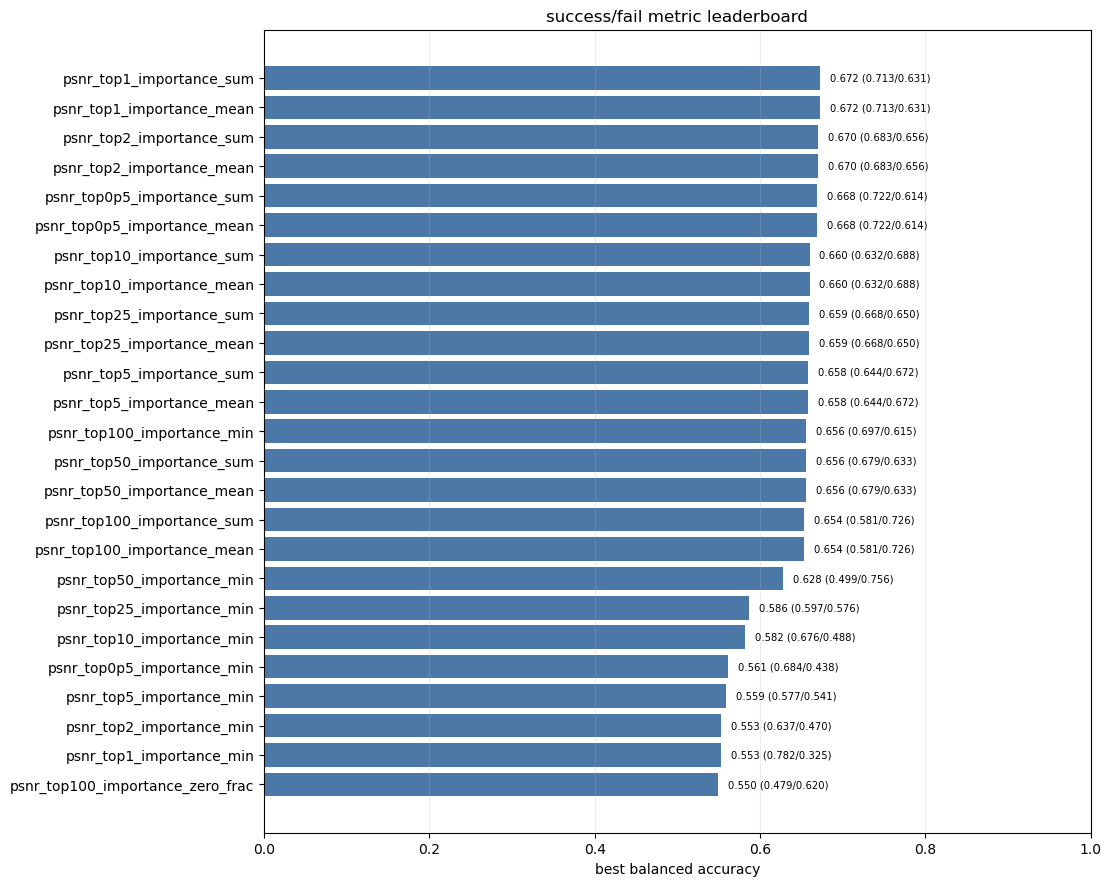

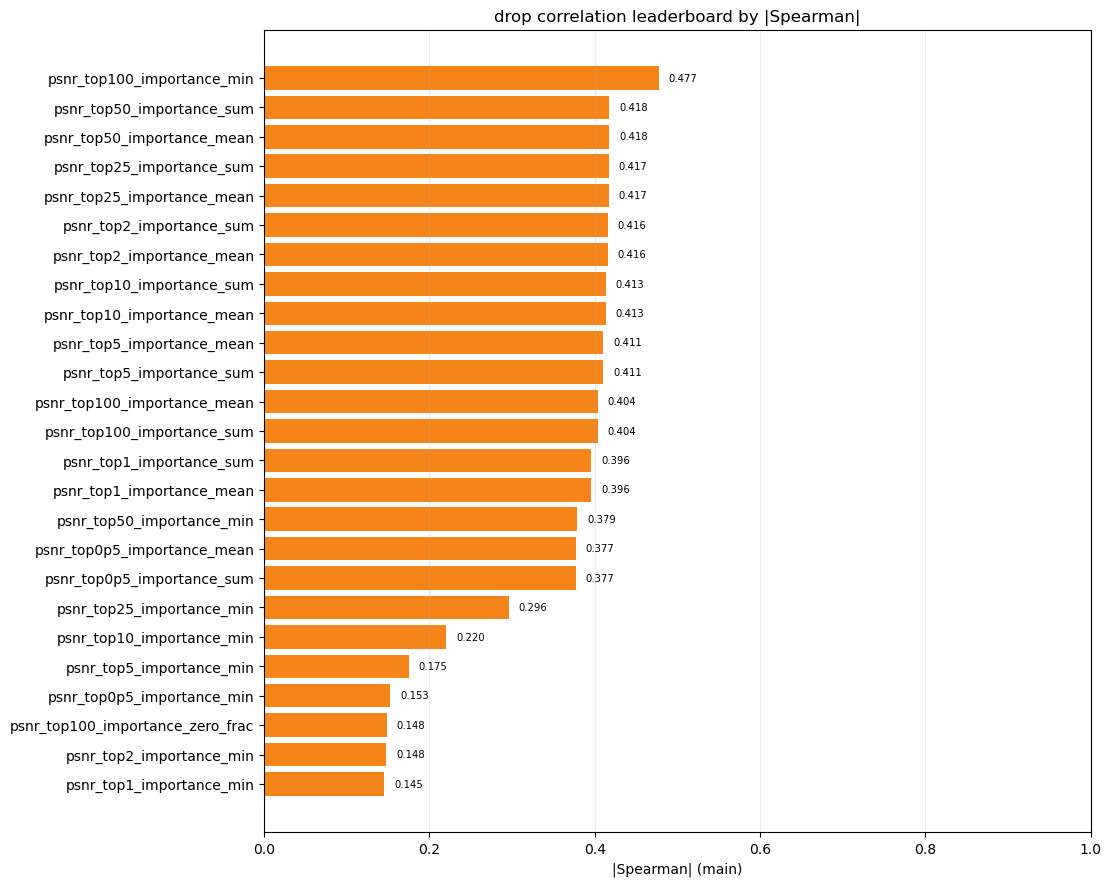

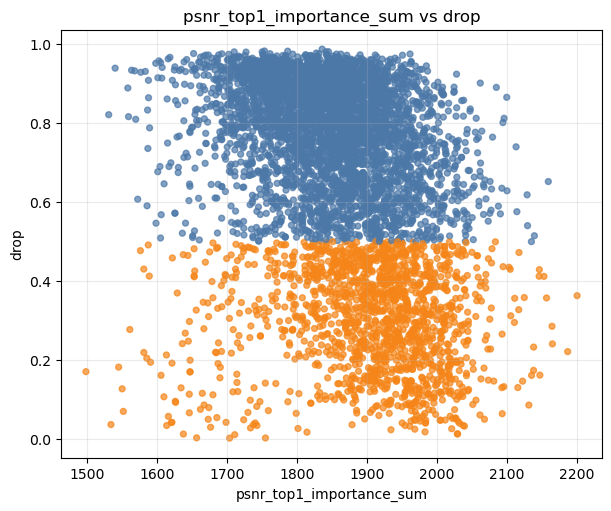

: 

In [ ]:
from classifier_patch_analysis.plots import plot_quality_leaderboard, plot_regression_leaderboard, plot_metric_vs_drop, savefig

fig = plot_quality_leaderboard(quality, top_n=25)
savefig(fig, exp.figures_dir / "psnr_balanced_accuracy_leaderboard.png")
fig = plot_regression_leaderboard(regression, top_n=25)
savefig(fig, exp.figures_dir / "psnr_drop_regression.png")
if not quality.empty:
    fig = plot_metric_vs_drop(rows_df, quality.iloc[0]["metric"])
    savefig(fig, exp.figures_dir / "psnr_best_metric_vs_drop.png")